# 09 — Benchmark report

Visualises the chunking × embedding × LLM sweep produced by
`python -m rag_evals.scripts.benchmark`. The script writes
`report/benchmark.json`; this notebook loads it and renders the same
tables + a few charts.

Re-run `make benchmark` (or the script directly) to refresh the JSON.


In [1]:
import json, pandas as pd
from pathlib import Path
from IPython.display import Markdown, display
bench = json.loads(Path("../report/benchmark.json").read_text())
print({k: type(v).__name__ for k, v in bench.items()})
bench["settings"]


{'settings': 'dict', 'has_mock_data': 'bool', 'mock_warning': 'NoneType', 'chunking_sweep': 'list', 'embedding_sweep': 'list', 'llm_sweep': 'list', 'pairwise': 'list'}


{'n_docs': 800,
 'n_queries': 30,
 'n_llm_queries': 15,
 'default_embedding': 'BAAI/bge-small-en-v1.5',
 'default_collection': 'scifact'}

## ⚠ Mock-data warning


In [2]:
# If the underlying benchmark run involved mock LLMs, every LLM-derived
# number below (faithfulness, latency, win-rates, sample answers) is
# a deterministic stub or fixture replay — NOT a real model evaluation.
if bench.get("has_mock_data"):
    display(Markdown(
        "> ⚠️  **MOCK DATA — NOT A REAL EVALUATION** ⚠️\n"
        ">\n"
        f"> {bench.get('mock_warning', '')}\n"
        ">\n"
        "> Rows tagged `[MOCK]` below were produced (in whole or in part) by a mock LLM."
    ))
else:
    print("benchmark.json reports no mock data — all rows are live.")


benchmark.json reports no mock data — all rows are live.


## Chunking sweep — embedding fixed, chunking varied


In [3]:
df_chunk = pd.DataFrame(bench["chunking_sweep"])
if not df_chunk.empty:
    cols = ["config", "n_chunks", "index_secs", "recall_at_10", "mrr", "ndcg_at_10", "map", "coverage"]
    display(df_chunk[cols].set_index("config"))


,n_chunks,index_secs,recall_at_10,mrr,ndcg_at_10,map,coverage
config,,,,,,,
recursive_256_32,1453,67.97,0.9000,0.7215,0.7596,0.7215,1.0
recursive_128_16,1593,76.44,0.8333,0.7104,0.7322,0.7104,1.0
recursive_512_64,895,41.54,0.8333,0.5842,0.6409,0.5842,1.0
structural_256,1453,68.30,0.9000,0.7215,0.7596,0.7215,1.0


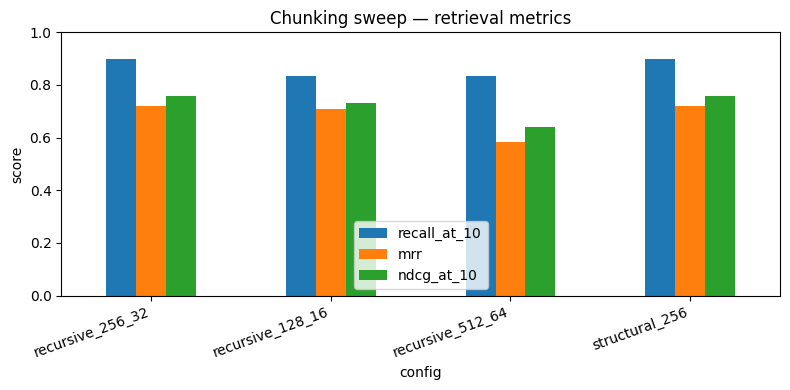

In [4]:
import matplotlib.pyplot as plt
if not df_chunk.empty:
    ax = df_chunk.set_index("config")[["recall_at_10", "mrr", "ndcg_at_10"]].plot(
        kind="bar", figsize=(8, 4), title="Chunking sweep — retrieval metrics"
    )
    ax.set_ylabel("score")
    ax.set_ylim(0, 1)
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()


## Embedding sweep — chunking fixed, embedding varied


In [5]:
df_emb = pd.DataFrame(bench["embedding_sweep"])
if not df_emb.empty:
    cols = ["config", "n_chunks", "index_secs", "recall_at_10", "mrr", "ndcg_at_10", "map", "coverage"]
    display(df_emb[cols].set_index("config"))


,n_chunks,index_secs,recall_at_10,mrr,ndcg_at_10,map,coverage
config,,,,,,,
bge-small-en-v1.5,1453,68.96,0.9000,0.7215,0.7596,0.7215,1.0000
all-MiniLM-L6-v2,1453,10.01,0.8333,0.6619,0.7009,0.6619,0.9583
bge-base-en-v1.5,1453,150.33,1.0000,0.7737,0.8283,0.7737,1.0000


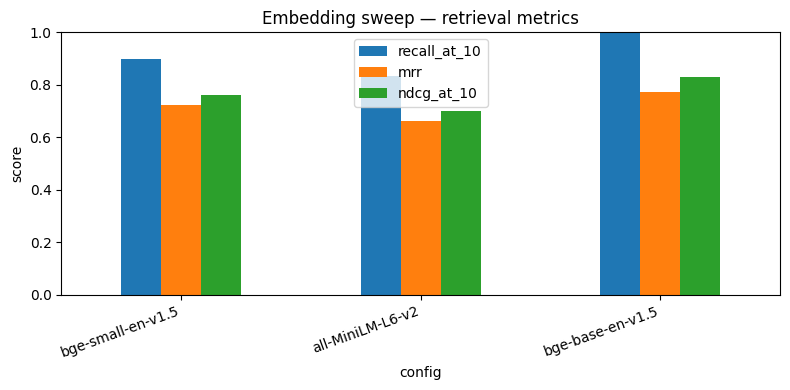

In [6]:
if not df_emb.empty:
    ax = df_emb.set_index("config")[["recall_at_10", "mrr", "ndcg_at_10"]].plot(
        kind="bar", figsize=(8, 4), title="Embedding sweep — retrieval metrics"
    )
    ax.set_ylabel("score")
    ax.set_ylim(0, 1)
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()


## LLM sweep — generator varies


In [7]:
df_llm = pd.DataFrame(bench["llm_sweep"])
if not df_llm.empty:
    # Tag mock rows so the dataframe view makes the contamination obvious.
    if "is_mock" in df_llm.columns:
        df_llm["model"] = df_llm.apply(
            lambda r: ("[MOCK] " if r.get("is_mock") else "") + r["model"], axis=1
        )
    display(df_llm.set_index("model"))
    if df_llm.get("is_mock", pd.Series(dtype=bool)).any():
        display(Markdown(
            "**⚠ Rows prefixed `[MOCK]` are not real evaluations — "
            "their faithfulness, latency, and sample answer come from "
            "MockBackend. Re-run with live API keys to replace.**"
        ))


,backend_mode,n_queries,avg_latency_ms,p95_latency_ms,faithfulness_heuristic,faithfulness_llm,n_failures,sample_answer,is_mock
model,,,,,,,,,
gpt-5-mini,live,15,4371.5,6033.9,0.3556,0.4178,0,I don't know.…,False
claude-haiku-4-5,live,15,2025.5,2337.7,0.1633,0.7683,0,I don't know. The provided context does not co...,False
gemini/gemini-2.5-flash,live,15,2702.7,3342.4,0.4000,0.6889,0,I don't know.…,False


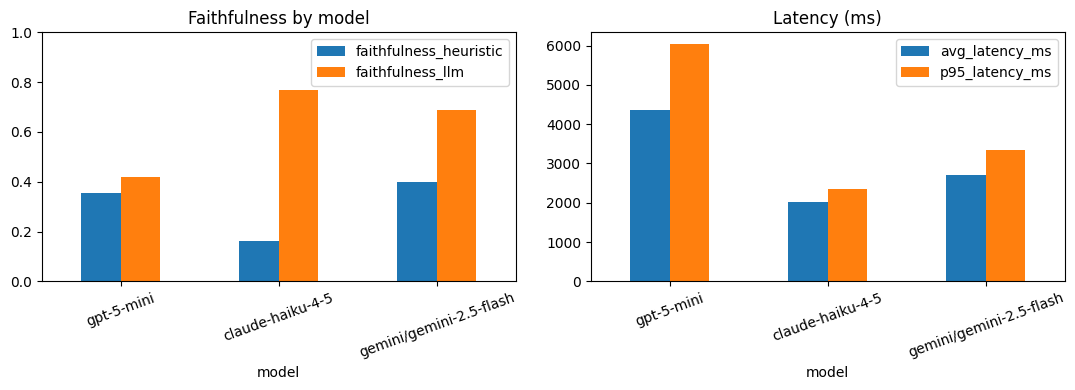

In [8]:
if not df_llm.empty:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    df_llm.set_index("model")[["faithfulness_heuristic", "faithfulness_llm"]].plot(
        kind="bar", ax=axes[0], title="Faithfulness by model"
    )
    axes[0].set_ylim(0, 1)
    df_llm.set_index("model")[["avg_latency_ms", "p95_latency_ms"]].plot(
        kind="bar", ax=axes[1], title="Latency (ms)"
    )
    if bench.get("has_mock_data"):
        for ax in axes:
            ax.set_title(ax.get_title() + "  (⚠ contains MOCK rows)")
    for ax in axes:
        ax.tick_params(axis="x", rotation=20)
    plt.tight_layout()
    plt.show()


## Pairwise judging (cross-family judge)


In [9]:
df_pw = pd.DataFrame(bench.get("pairwise", []))
if not df_pw.empty:
    if "is_mock" in df_pw.columns and df_pw["is_mock"].any():
        df_pw = df_pw.copy()
        df_pw["a"] = df_pw.apply(lambda r: ("[MOCK] " if r["is_mock"] else "") + r["a"], axis=1)
        df_pw["b"] = df_pw.apply(lambda r: ("[MOCK] " if r["is_mock"] else "") + r["b"], axis=1)
        display(df_pw)
        display(Markdown(
            "**⚠ `[MOCK]`-tagged rows had at least one mock generator — "
            "win counts reflect a deterministic stub, not real preference.**"
        ))
    else:
        display(df_pw)
else:
    print("no pairwise data — re-run with live LLM keys to populate")


,judge,a,b,a_wins,b_wins,ties,is_mock,winrate_a
0,gemini/gemini-2.5-flash,gpt-5-mini,claude-haiku-4-5,6,9,0,False,0.400000
1,claude-haiku-4-5,gpt-5-mini,gemini/gemini-2.5-flash,12,3,0,False,0.800000
2,gpt-5-mini,claude-haiku-4-5,gemini/gemini-2.5-flash,10,5,0,False,0.666667
